# **Sentiment Analysis using NLP Pipeline & ML Models**





This project implements a complete sentiment analysis pipeline that converts raw textual data into meaningful insights using NLP and machine learning. Initially, the dataset is explored to understand its structure and sentiment distribution. The text is then preprocessed by cleaning noise such as punctuation, stopwords, URLs, and emojis, and applying tokenization and lemmatization to standardize the data. Next, the processed text is transformed into numerical features using techniques like Bag of Words and TF-IDF, enabling machine learning models to interpret the text. Multiple models, including Logistic Regression, Naive Bayes, and Decision Tree, are trained and evaluated using metrics such as accuracy, precision, recall, and F1 score. Finally, the models are compared to identify the most effective approach, providing insights into the best preprocessing techniques, feature representations, and model performance.


# **1. Data Understanding**

**Importing Necessary Libraries**

In [2]:
!pip install nltk scikit-learn seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [15]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

**Upload Dataset and Load Dataset**

In [3]:
df = pd.read_csv("amazon_reviews.csv")
df.head()

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,767db26c-658a-4b18-8808-97a61acf9ec1,Jane King,Easy to shop and easy to return without ask. T...,5,0,32.6.0.100,2026-03-28 07:55:15,32.6.0.100
1,50b86ce0-00bb-4213-821c-0acc44aefa37,Mari Rose,not only does nothing actually arrive when it'...,1,0,32.5.0.100,2026-03-28 07:36:17,32.5.0.100
2,e5bc0333-deaa-433e-a885-889cf0506055,Steve Flin,"wrong phone ""detected"" from previous previous ...",3,0,32.6.0.100,2026-03-28 07:00:28,32.6.0.100
3,055d5582-2f1a-49a2-a329-ca36ecbf907e,FatheredPuma81,Decided to uninstall after customer service tr...,1,1,32.6.0.100,2026-03-28 06:11:43,32.6.0.100
4,63203af9-7e91-40d9-b1bd-86aa7b5f5405,Sabbir Rohman,এই অ্যাপসটা অনেক ভালো কিন্তুক,5,0,NaN,2026-03-28 05:48:07,NaN


**Fetching Basic Information**

In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)

Shape: (85824, 8)

Columns: Index(['reviewId', 'userName', 'content', 'score', 'thumbsUpCount',
       'reviewCreatedVersion', 'at', 'appVersion'],
      dtype='object')


**Function and coloumn creation for assinging the sentiment(positive,neutral,negative) based on score value**

In [8]:
def get_sentiment(score):
    if score <= 2:
        return 0   # Negative
    elif score == 3:
        return 1   # Neutral
    else:
        return 2   # Positive

df['sentiment'] = df['score'].apply(get_sentiment)

**Class Distribution (Bar Graph)**

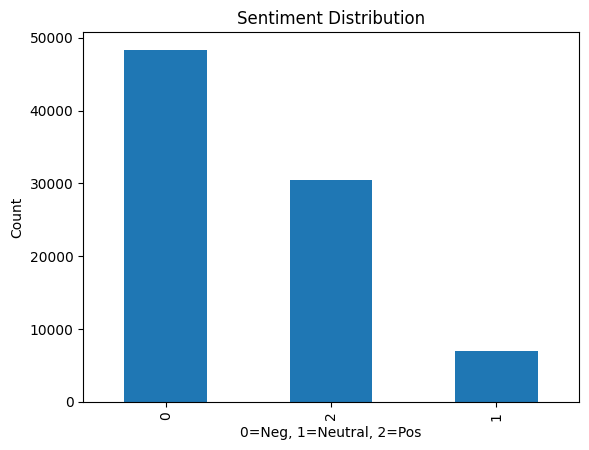

In [9]:
df['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("0=Neg, 1=Neutral, 2=Pos")
plt.ylabel("Count")

plt.show()

**Pie Chart**

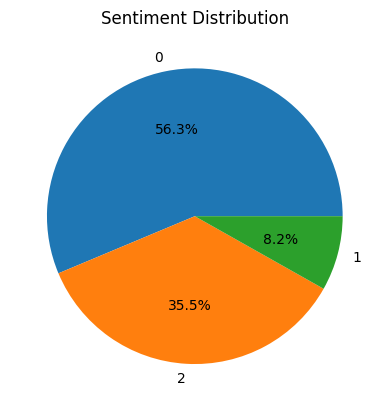

In [10]:
df['sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.ylabel("")
plt.show()

In [11]:
print(df['content'][0])

Easy to shop and easy to return without ask. Thanks 😊


# **2. NLP Preprocessing**


**Create Preprocessing Function**

In [16]:
import re
import string
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove emojis
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords + lemmatization
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

**Apply Preprocessing**

In [17]:
df['clean_text'] = df['content'].apply(preprocess_text)

df[['content','clean_text']].head()

,content,clean_text
0,Easy to shop and easy to return without ask. T...,easy shop easy return without ask thanks
1,not only does nothing actually arrive when it'...,nothing actually arrive supposed im forced use...
2,"wrong phone ""detected"" from previous previous ...",wrong phone detected previous previous phone x...
3,Decided to uninstall after customer service tr...,decided uninstall customer service tried gasli...
4,এই অ্যাপসটা অনেক ভালো কিন্তুক,


**Removeing rows with missing text and creating original_length and clean_length columns**

In [21]:
df = df.dropna(subset=['content'])  # remove rows with missing text

In [23]:
df['content'] = df['content'].astype(str)

In [24]:
df['original_length'] = df['content'].apply(lambda x: len(str(x)))
df['clean_length'] = df['clean_text'].apply(lambda x: len(str(x)))

**Before vs After Preprocessing (Histogram)**

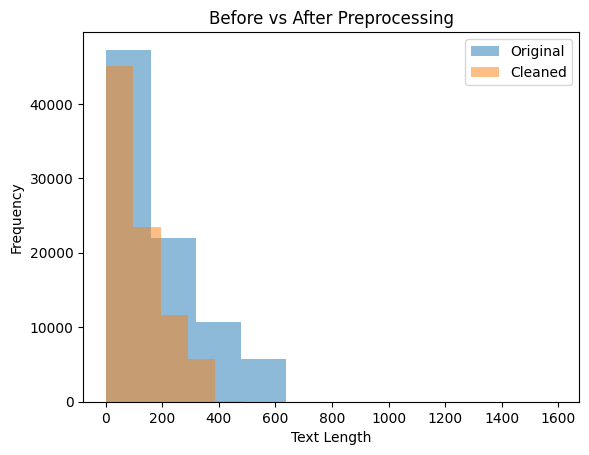

In [25]:
import matplotlib.pyplot as plt

plt.hist(df['original_length'], alpha=0.5, label='Original')
plt.hist(df['clean_length'], alpha=0.5, label='Cleaned')

plt.legend()
plt.title("Before vs After Preprocessing")
plt.xlabel("Text Length")
plt.ylabel("Frequency")

plt.show()

# **3. Feature Engineering**


**Train-Test Split**

In [26]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### **Bag of Words (BoW)**

In [27]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

### **TF-IDF**

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

**Top Words Visualization**

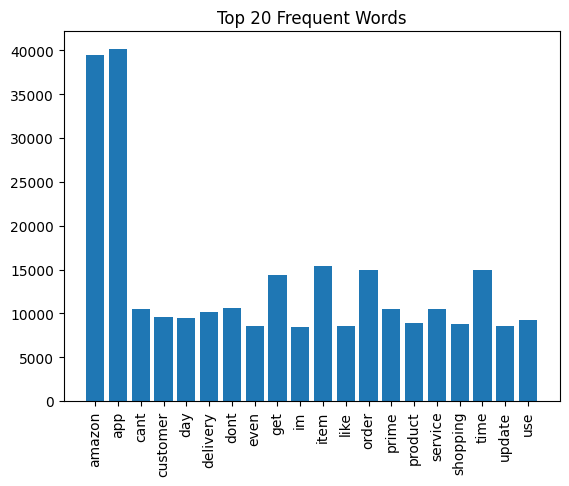

In [30]:
bow_small = CountVectorizer(max_features=20)
X_bow_small = bow_small.fit_transform(df['clean_text'])

words = bow_small.get_feature_names_out()
counts = np.sum(X_bow_small.toarray(), axis=0)

plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Top 20 Frequent Words")
plt.show()

# **4. Model Building**


**Logistic Regression**

In [31]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

**Naive Bayes**

In [32]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

**Decision Tree**

In [33]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train_tfidf, y_train)

y_pred_dt = dt.predict(X_test_tfidf)

# **5. Model Evaluation**


**Evaluation Function**

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(name, y_test, y_pred):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

**Evaluate Models**

In [37]:
evaluate("Logistic Regression", y_test, y_pred_lr)
evaluate("Naive Bayes", y_test, y_pred_nb)
evaluate("Decision Tree", y_test, y_pred_dt)


Logistic Regression
Accuracy: 0.8376929799009613
Precision: 0.8028738985241148
Recall: 0.8376929799009613
F1 Score: 0.8067948959945769

Naive Bayes
Accuracy: 0.8258665889892223
Precision: 0.7826893650470749
Recall: 0.8258665889892223
F1 Score: 0.7892953283298735

Decision Tree
Accuracy: 0.7420914651907953
Precision: 0.7295755077280375
Recall: 0.7420914651907953
F1 Score: 0.7354551576818238


**Confusion Matrix**

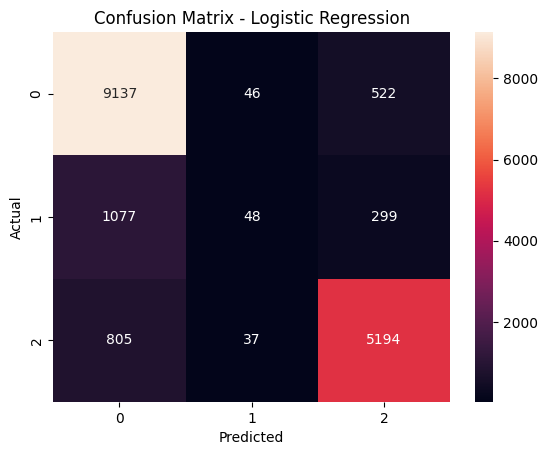

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **6. Comparison & Insights**


**Accuracy Comparison Graph**

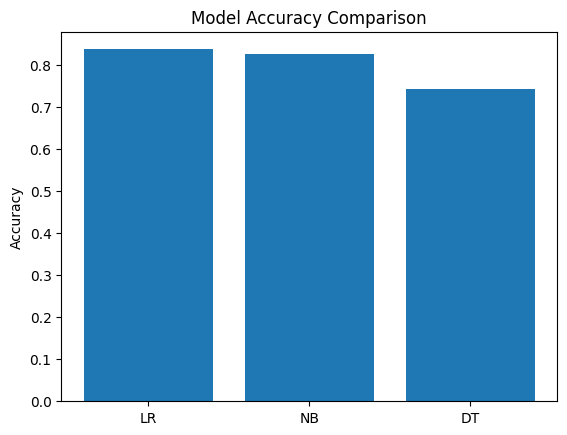

In [39]:
models = ['LR', 'NB', 'DT']

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_dt)
]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

**Precision, Recall, F1 Graph**

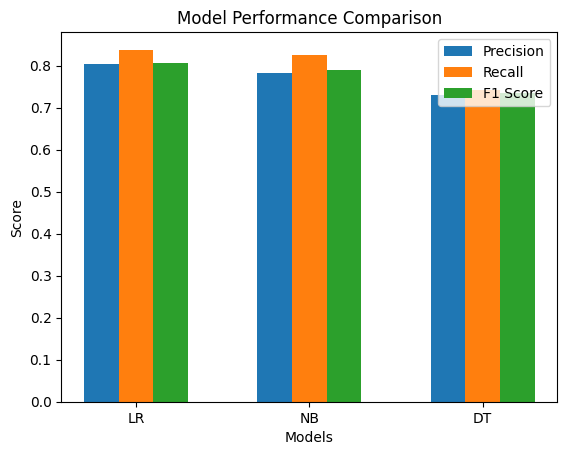

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = [
    precision_score(y_test, y_pred_lr, average='weighted'),
    precision_score(y_test, y_pred_nb, average='weighted'),
    precision_score(y_test, y_pred_dt, average='weighted')
]

recall = [
    recall_score(y_test, y_pred_lr, average='weighted'),
    recall_score(y_test, y_pred_nb, average='weighted'),
    recall_score(y_test, y_pred_dt, average='weighted')
]

f1 = [
    f1_score(y_test, y_pred_lr, average='weighted'),
    f1_score(y_test, y_pred_nb, average='weighted'),
    f1_score(y_test, y_pred_dt, average='weighted')
]

x = np.arange(len(models))

plt.bar(x-0.2, precision, 0.2, label='Precision')
plt.bar(x, recall, 0.2, label='Recall')
plt.bar(x+0.2, f1, 0.2, label='F1 Score')

plt.xticks(x, models)
plt.legend()
plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")

plt.show()